In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta

In [3]:
sector_etfs = {
    "XLC": "Communication Services",
    "XLE": "Energy",
    "XLF": "Financials",
    "XLI": "Industrials",
    "XLK": "Technology",
    "XLB": "Materials",
    "XLRE": "Real Estate",
    "XLU": "Utilities",
    "XLV": "Healthcare",
    "XLY": "Consumer Discretionary"
}

In [4]:
#Define time range(last 5 years)
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=5*365)).strftime('%Y-%m-%d')

#Fecth stock data for each sector ETF
sector_performance = {}

In [5]:
for etf, industry in sector_etfs.items():
  print(f"Fetching data for {industry} ({etf})...")  # Debugging output

  try:
      industry_stock_data = yf.download(etf, start=start_date, end=end_date)

      if industry_stock_data.empty:
          print(f"No data found for {industry} ({etf}). Skipping...\n")
          continue

      #Calculate 5-year return
      initial_price = industry_stock_data["Close"].iloc[0]
      latest_price = industry_stock_data["Close"].iloc[-1]
      percent_change = ((latest_price - initial_price) / initial_price) * 100

      #Store results
      sector_performance[industry] = percent_change.iloc[0] #Store the numeric value

      #Print formatted output
      print(f"{industry} ({etf}): {percent_change.iloc[0]:.2f}% return in 5 years\n")

  except Exception as e:
      print(f"Error fetching data for {industry} ({etf}): {e}\n")
      sector_performance[industry] = float('nan')
      time.sleep(2)

Fetching data for Communication Services (XLC)...


/tmp/ipykernel_16/995411619.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  industry_stock_data = yf.download(etf, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16/995411619.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  industry_stock_data = yf.download(etf, start=start_date, end=end_date)


Communication Services (XLC): 43.46% return in 5 years

Fetching data for Energy (XLE)...


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16/995411619.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  industry_stock_data = yf.download(etf, start=start_date, end=end_date)


Energy (XLE): 180.98% return in 5 years

Fetching data for Financials (XLF)...


...

Utilities (XLU): 62.10% return in 5 years

Fetching data for Healthcare (XLV)...


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16/995411619.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  industry_stock_data = yf.download(etf, start=start_date, end=end_date)


Healthcare (XLV): 35.38% return in 5 years

Fetching data for Consumer Discretionary (XLY)...


[*********************100%***********************]  1 of 1 completed

Consumer Discretionary (XLY): 33.02% return in 5 years



In [6]:
df_performance = pd.DataFrame.from_dict(sector_performance, orient='index', columns=["5-Year Return(%)"])
df_performance = df_performance.sort_values(by="5-Year Return(%)", ascending=False)

df_performance_top10= df_performance.head(10)
print(df_performance_top10)

                        5-Year Return(%)
Energy                        180.975184
Technology                    140.066115
Industrials                    86.851222
Financials                     67.633938
Utilities                      62.100517
Communication Services         43.461018
Materials                      37.536569
Healthcare                     35.383806
Consumer Discretionary         33.015640
Real Estate                    16.232720


                        5-Year Return(%)
Energy                        180.975184
Technology                    140.066115
Industrials                    86.851222
Financials                     67.633938
Utilities                      62.100517
Communication Services         43.461018
Materials                      37.536569
Healthcare                     35.383806
Consumer Discretionary         33.015640
Real Estate                    16.232720


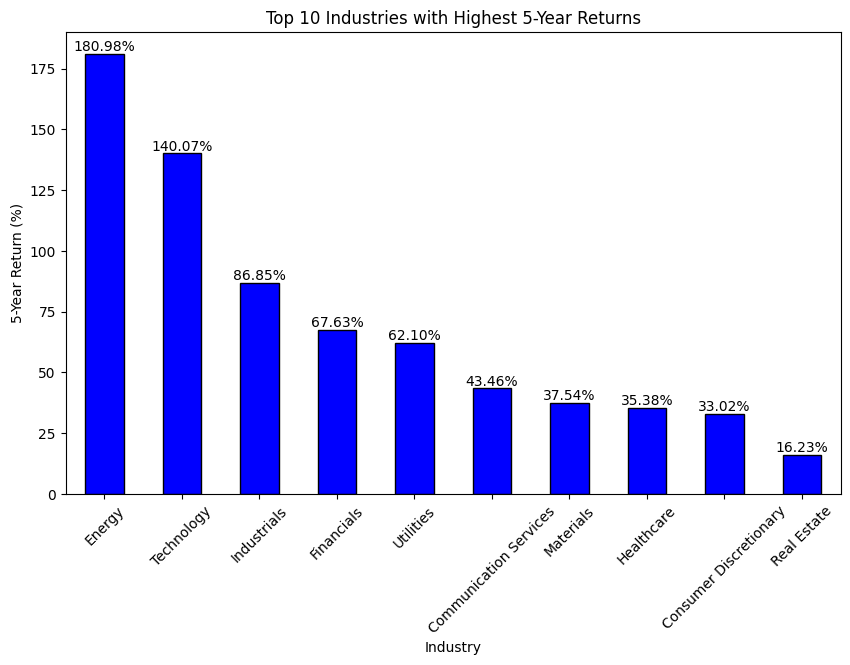

In [7]:
df_performance_top10= df_performance.head(10)
print(df_performance_top10)

plt.figure(figsize=(10,6))
bars = df_performance_top10["5-Year Return(%)"].plot(kind="bar", color='blue', edgecolor='black') 
plt.title("Top 10 Industries with Highest 5-Year Returns")
plt.xlabel("Industry")
plt.ylabel("5-Year Return (%)")
plt.xticks(rotation=45)

# Add data labels to the bars
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.2f}%', 
                   (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                   ha='center', va='bottom')

plt.show()

## **Part II**
__Investigate top 3 companies of top 4 sectors__
* Energy
* Technology
* Industrials
* Financials

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

sectors = {
    "Energy": "energy",
    "Technology": "technology",
    "Industrials": "industrials",
    "Financials": "financial-services"
}
top_n = 3

def get_market_cap(sym, retries=3, delay=1.0):
    for attempt in range(retries):
        try:
            mc = yf.Ticker(sym).info.get("marketCap")
            if mc is not None:
                return mc
        except Exception as e:
            print(f"  ⚠ Attempt {attempt+1} failed for {sym}: {e}")
        time.sleep(delay)
    print(f"  ⚠ Giving up on {sym} after {retries} attempts")
    return None

def get_market_cap(sym, retries=3, delay=1.0):
    for attempt in range(retries):
        try:
            mc = yf.Ticker(sym).info.get("marketCap")
            if mc is not None:
                return mc
        except Exception as e:
            print(f"  ⚠ Attempt {attempt+1} failed for {sym}: {e}")
        time.sleep(delay)
    print(f"  ⚠ Giving up on {sym} after {retries} attempts")
    return None

def get_top_companies(sector_name, sector_key, top_n=3):
    print(f"\n Fetching top {top_n} companies in {sector_name} sector...")
    try:
        sector = yf.Sector(sector_key)
        df = sector.top_companies

        if df is None or df.empty:
            print(f"⚠ No data found for {sector_name}.")
            return pd.DataFrame()

        df = df.head(top_n).reset_index()

        market_caps = []
        for sym in df["symbol"]:
            mc = get_market_cap(sym)
            market_caps.append(mc)
            time.sleep(0.5)  # pace requests between tickers too

        df["Market Cap"] = market_caps
        df = df.rename(columns={"symbol": "Ticker", "name": "Company"})
        result = df[["Ticker", "Company", "Market Cap"]].dropna(subset=["Market Cap"])

        if len(result) < top_n:
            print(f"  ⚠ Only {len(result)}/{top_n} companies had usable data for {sector_name}")

        return result
    except Exception as e:
        print(f" Error fetching data for {sector_name}: {e}")
        return pd.DataFrame()


 Fetching top 3 companies in Energy sector...
  ⚠ Giving up on XOM after 3 attempts
  ⚠ Only 2/3 companies had usable data for Energy

 Fetching top 3 companies in Technology sector...

 Fetching top 3 companies in Industrials sector...
  ⚠ Giving up on CAT after 3 attempts
  ⚠ Only 2/3 companies had usable data for Industrials

 Fetching top 3 companies in Financials sector...
  ⚠ Giving up on JPM after 3 attempts
  ⚠ Giving up on V after 3 attempts
  ⚠ Only 1/3 companies had usable data for Financials

 Top 3 Companies in Energy:
Ticker             Company   Market Cap
   CVX Chevron Corporation 3.731856e+11
   COP      ConocoPhillips 1.397505e+11
--------------------

 Top 3 Companies in Technology:
Ticker               Company    Market Cap
  NVDA    NVIDIA Corporation 4912260841472
  AAPL            Apple Inc. 4901757779968
  MSFT Microsoft Corporation 2925466222592
--------------------

 Top 3 Companies in Industrials:
Ticker                              Company   Market Cap
  S

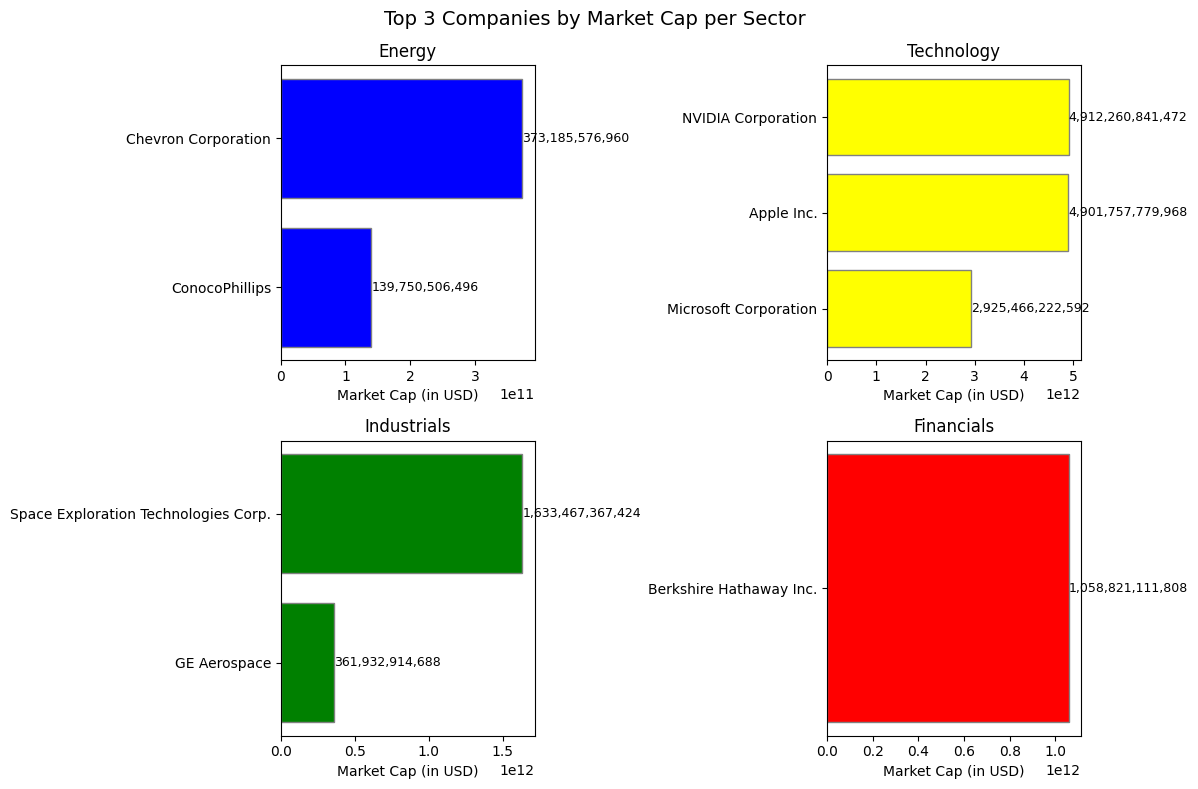

In [9]:
results = {}
for sector_name, sector_key in sectors.items():
    top_companies = get_top_companies(sector_name, sector_key, top_n)
    if not top_companies.empty:
        results[sector_name] = top_companies

for sector_name, top_companies in results.items():
    print(f"\n Top {top_n} Companies in {sector_name}:")
    print(top_companies.to_string(index=False))
    print("-" * 20)

if results:
    sector_colors = {
        "Energy": "blue",
        "Technology": "yellow",
        "Industrials": "green",
        "Financials": "red"
    }

    n_sectors = len(results)
    n_cols = 2
    n_rows = -(-n_sectors // n_cols)  # ceil division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten() if n_sectors > 1 else [axes]

    for ax, (sector_name, df_sector) in zip(axes, results.items()):
        df_sector = df_sector.sort_values("Market Cap", ascending=True)
        color = sector_colors.get(sector_name, "grey")

        ax.barh(df_sector["Company"], df_sector["Market Cap"], color=color, edgecolor='grey')
        ax.set_title(sector_name)
        ax.set_xlabel("Market Cap (in USD)")

        for i, v in enumerate(df_sector["Market Cap"]):
            ax.text(v, i, f"{v:,.0f}", ha="left", va="center", fontsize=9)

    # Hide any unused subplot slots (e.g. odd number of sectors)
    for ax in axes[n_sectors:]:
        ax.axis("off")

    fig.suptitle(f"Top {top_n} Companies by Market Cap per Sector", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠ No data found. Ensure your API key is correct.")